In [1]:
print('hello everyone today we will learn about XGBoost & LightGBM')

hello everyone today we will learn about XGBoost & LightGBM


In [2]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install xgboost
!pip install lightgbm

In [3]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
url = "https://raw.githubusercontent.com/ybifoundation/Dataset/main/Bank%20Churn%20Modelling.csv"
df = pd.read_csv(url)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'Num Of Products', 'Has Credit Card',
       'Is Active Member', 'Estimated Salary', 'Churn'],
      dtype='object')

In [6]:
df.isna().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
Num Of Products,0
Has Credit Card,0


In [8]:
df.shape

(10000, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num Of Products   10000 non-null  int64  
 9   Has Credit Card   10000 non-null  int64  
 10  Is Active Member  10000 non-null  int64  
 11  Estimated Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [10]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
label_encoder = LabelEncoder()
df['EncodedGeography'] = label_encoder.fit_transform(df['Geography'])
df['EncodedGender'] = label_encoder.fit_transform(df['Gender'])
df.drop(['CustomerId','Surname'], axis=1, inplace=True)


In [16]:
X= df.drop(["Churn","Gender", "Geography"], axis=1)
y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
from dask.utils import random_state_data
xgboost_model = XGBClassifier(n_estimators= 200, max_depth= 4, learning_rate= 0.05,
                              subsample= 0.8, colsample_bytree= 0.8, random_state=42, eval_metric= "logloss")
xgboost_model.fit(X_train, y_train)
y_pred_xgb = xgboost_model.predict(X_test)

In [64]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)

print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)

Accuracy : 0.8665
Precision : 0.7480314960629921


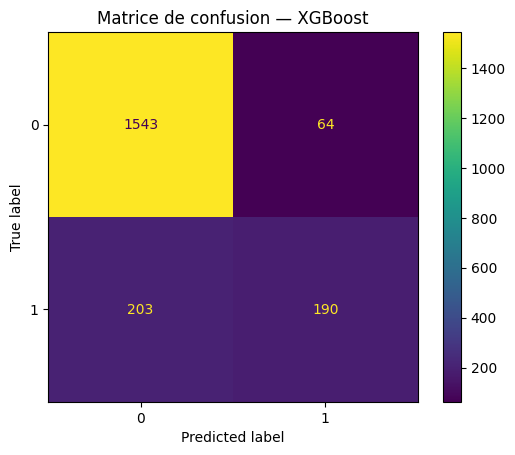

In [51]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb
)

plt.title("Matrice de confusion — XGBoost")
plt.show()

In [52]:
lgbm_model =  LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

In [53]:
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_precision = precision_score(y_test, y_pred_lgbm)

print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)

Accuracy : 0.8665
Precision : 0.7480314960629921


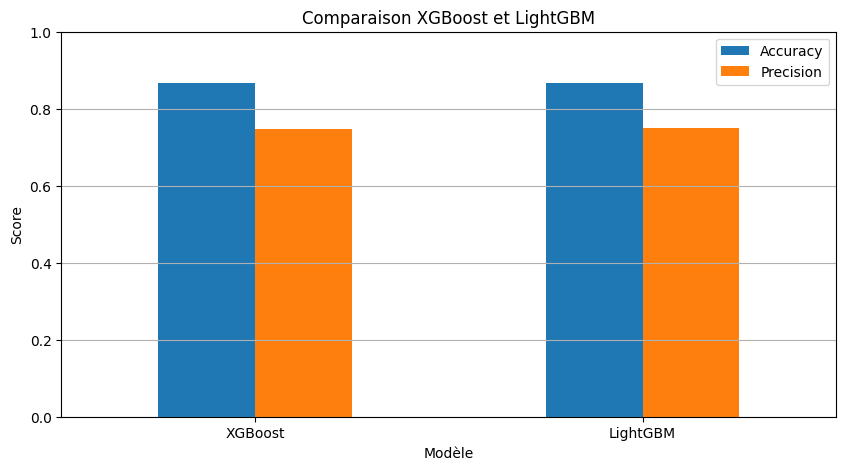

In [54]:
results = pd.DataFrame({
    "Modèle": ["XGBoost", "LightGBM"],
    "Accuracy": [xgb_accuracy, lgbm_accuracy],
    "Precision": [xgb_precision, lgbm_precision]
})
results.set_index("Modèle").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparaison XGBoost et LightGBM")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()